# Dars 1: Data Tozalash va Tayyorlash

## 📚 Kirish

Data Science loyihasining 80% vaqti ma'lumotlarni tozalash va tayyorlashga sarflanadi. Real dunyo ma'lumotlari:
- ❌ Noto'liq (missing values)
- ❌ Takroriy (duplicates)
- ❌ Noto'g'ri formatda
- ❌ Kategorik (son emas)

**Bugungi darsda biz bu muammolarni hal qilishni o'rganamiz!**

## 📦 Kutubxonalarni Yuklash

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Vizualizatsiya sozlamalari
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ma'lumotlarni to'liq ko'rsatish
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Barcha kutubxonalar yuklandi!")

✅ Barcha kutubxonalar yuklandi!


---
## 1️⃣ Missing Values (Yetishmayotgan Qiymatlar)

### Missing Values nima?

Missing values - bu ma'lumotlar to'plamida bo'sh yoki mavjud bo'lmagan qiymatlar.

**Sabablari:**
- Ma'lumot yig'ilmagan
- Ma'lumot yo'qolgan
- Javob berilmagan (survey)
- Sensor ishlamagan
- Data entry xatosi

### 1.1. Misol Ma'lumotlar Yaratish

In [31]:
# Misol: Talabalar ma'lumotlari
data = {
    'Ism': ['Ali', 'Vali', 'Sardor', 'Malika', 'Nigora', 'Aziz', 'Dildora', 'Jasur'],
    'Yosh': [20, 22, np.nan, 21, 23, np.nan, 20, 22],
    'Ball': [85, np.nan, 92, 78, np.nan, 88, 95, np.nan],
    'Shahar': ['Toshkent', 'Samarqand', np.nan, 'Toshkent', 'Buxoro', 'Toshkent', np.nan, 'Samarqand'],
    'Kurs': [1, 2, 2, 1, 3, np.nan, 1, 2]
}

df = pd.DataFrame(data)
print("📊 Talabalar Ma'lumotlari:")
print(df)
print(f"\n📏 Ma'lumotlar o'lchami: {df.shape}")

📊 Talabalar Ma'lumotlari:
       Ism  Yosh  Ball     Shahar  Kurs
0      Ali  20.0  85.0   Toshkent   1.0
1     Vali  22.0   NaN  Samarqand   2.0
2   Sardor   NaN  92.0        NaN   2.0
3   Malika  21.0  78.0   Toshkent   1.0
4   Nigora  23.0   NaN     Buxoro   3.0
5     Aziz   NaN  88.0   Toshkent   NaN
6  Dildora  20.0  95.0        NaN   1.0
7    Jasur  22.0   NaN  Samarqand   2.0

📏 Ma'lumotlar o'lchami: (8, 5)


### 1.2. Missing Values ni Aniqlash

In [32]:
# Usul 1: isnull() yoki isna()
print("🔍 Missing values (True/False):")
print(df.isnull())
print("\n" + "="*50)

🔍 Missing values (True/False):
     Ism   Yosh   Ball  Shahar   Kurs
0  False  False  False   False  False
1  False  False   True   False  False
2  False   True  False    True  False
3  False  False  False   False  False
4  False  False   True   False  False
5  False   True  False   False   True
6  False  False  False    True  False
7  False  False   True   False  False



In [33]:
# Usul 2: Har bir ustundagi missing values soni
print("📊 Har bir ustundagi missing values:")
print(df.isnull().sum())
print("\n" + "="*50)

📊 Har bir ustundagi missing values:
Ism       0
Yosh      2
Ball      3
Shahar    2
Kurs      1
dtype: int64



In [34]:
# Usul 3: Missing values foizi
print("📈 Missing values foizi:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage': missing_percentage
})
print(missing_info)
print(f"\n🔢 Jami missing values: {df.isnull().sum().sum()}")

📈 Missing values foizi:
        Missing Count  Percentage
Ism                 0         0.0
Yosh                2        25.0
Ball                3        37.5
Shahar              2        25.0
Kurs                1        12.5

🔢 Jami missing values: 8


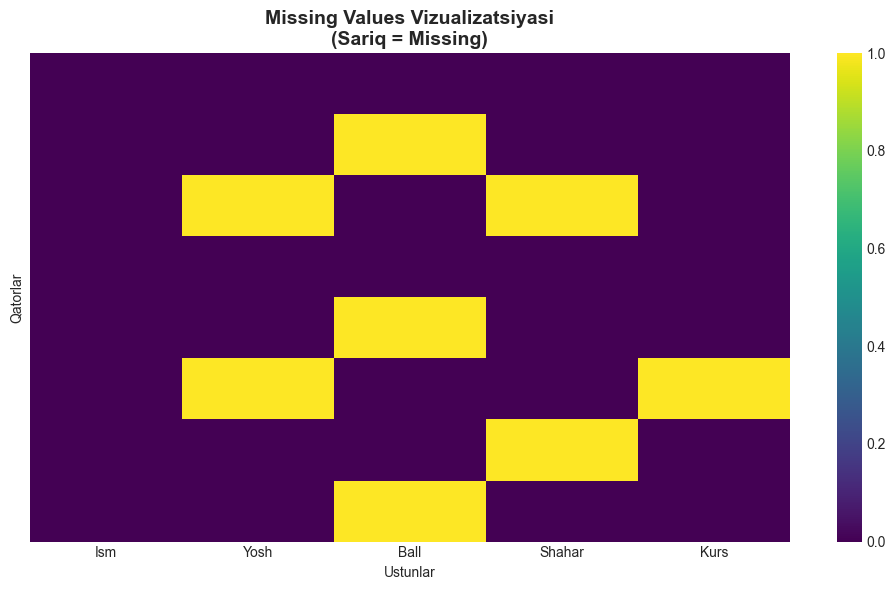

In [35]:
# Usul 4: Vizualizatsiya
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Vizualizatsiyasi\n(Sariq = Missing)', fontsize=14, fontweight='bold')
plt.xlabel('Ustunlar')
plt.ylabel('Qatorlar')
plt.tight_layout()
plt.show()

### 1.3. Missing Values bilan Ishlash Strategiyalari

#### 📌 Strategiya 1: O'chirish (Deletion)

**Qachon ishlatiladi:**
- Missing values juda oz (<5%)
- Ma'lumotlar ko'p
- Missing data random

In [36]:
# A) Qatorlarni o'chirish (har qanday missing value bo'lsa)
df_dropped_rows = df.dropna()
print("🗑️ Missing value bo'lgan qatorlarni o'chirish:")
print(df_dropped_rows)
print(f"\n📏 Yangi o'lcham: {df_dropped_rows.shape} (Eski: {df.shape})")
print(f"❌ O'chirildi: {len(df) - len(df_dropped_rows)} qator")

🗑️ Missing value bo'lgan qatorlarni o'chirish:
      Ism  Yosh  Ball    Shahar  Kurs
0     Ali  20.0  85.0  Toshkent   1.0
3  Malika  21.0  78.0  Toshkent   1.0

📏 Yangi o'lcham: (2, 5) (Eski: (8, 5))
❌ O'chirildi: 6 qator


In [37]:
# B) Ma'lum bir ustundagi missing values bo'yicha o'chirish
df_dropped_ball = df.dropna(subset=['Ball'])
print("🗑️ Faqat 'Ball' ustunidagi missing values bo'yicha:")
print(df_dropped_ball)
print(f"\n📏 Yangi o'lcham: {df_dropped_ball.shape}")

🗑️ Faqat 'Ball' ustunidagi missing values bo'yicha:
       Ism  Yosh  Ball    Shahar  Kurs
0      Ali  20.0  85.0  Toshkent   1.0
2   Sardor   NaN  92.0       NaN   2.0
3   Malika  21.0  78.0  Toshkent   1.0
5     Aziz   NaN  88.0  Toshkent   NaN
6  Dildora  20.0  95.0       NaN   1.0

📏 Yangi o'lcham: (5, 5)


In [38]:
# C) Ustunlarni o'chirish
df_dropped_cols = df.dropna(axis=1)
print("🗑️ Missing value bo'lgan ustunlarni o'chirish:")
print(df_dropped_cols)
print(f"\n📏 Yangi o'lcham: {df_dropped_cols.shape}")

🗑️ Missing value bo'lgan ustunlarni o'chirish:
       Ism
0      Ali
1     Vali
2   Sardor
3   Malika
4   Nigora
5     Aziz
6  Dildora
7    Jasur

📏 Yangi o'lcham: (8, 1)


#### 📌 Strategiya 2: To'ldirish (Imputation)

**Qachon ishlatiladi:**
- Missing values ko'p
- Ma'lumotlar kam
- Missing data important

In [39]:
# A) Ma'lum bir qiymat bilan to'ldirish
df_filled_zero = df.copy()
df_filled_zero['Ball'] = df_filled_zero['Ball'].fillna(0)
print("✏️ Missing values ni 0 bilan to'ldirish:")
print(df_filled_zero)
print("\n⚠️ Eslatma: 0 bilan to'ldirish har doim to'g'ri emas!")

✏️ Missing values ni 0 bilan to'ldirish:
       Ism  Yosh  Ball     Shahar  Kurs
0      Ali  20.0  85.0   Toshkent   1.0
1     Vali  22.0   0.0  Samarqand   2.0
2   Sardor   NaN  92.0        NaN   2.0
3   Malika  21.0  78.0   Toshkent   1.0
4   Nigora  23.0   0.0     Buxoro   3.0
5     Aziz   NaN  88.0   Toshkent   NaN
6  Dildora  20.0  95.0        NaN   1.0
7    Jasur  22.0   0.0  Samarqand   2.0

⚠️ Eslatma: 0 bilan to'ldirish har doim to'g'ri emas!


In [40]:
# B) O'rtacha qiymat (Mean) bilan to'ldirish
df_filled_mean = df.copy()
mean_ball = df['Ball'].mean()
df_filled_mean['Ball'] = df_filled_mean['Ball'].fillna(mean_ball)

mean_yosh = df['Yosh'].mean()
df_filled_mean['Yosh'] = df_filled_mean['Yosh'].fillna(mean_yosh)

print(f"✏️ Ball o'rtachasi: {mean_ball:.2f}")
print(f"✏️ Yosh o'rtachasi: {mean_yosh:.2f}")
print("\n📊 Mean bilan to'ldirilgan ma'lumotlar:")
print(df_filled_mean)

✏️ Ball o'rtachasi: 87.60
✏️ Yosh o'rtachasi: 21.33

📊 Mean bilan to'ldirilgan ma'lumotlar:
       Ism       Yosh  Ball     Shahar  Kurs
0      Ali  20.000000  85.0   Toshkent   1.0
1     Vali  22.000000  87.6  Samarqand   2.0
2   Sardor  21.333333  92.0        NaN   2.0
3   Malika  21.000000  78.0   Toshkent   1.0
4   Nigora  23.000000  87.6     Buxoro   3.0
5     Aziz  21.333333  88.0   Toshkent   NaN
6  Dildora  20.000000  95.0        NaN   1.0
7    Jasur  22.000000  87.6  Samarqand   2.0


In [ ]:
# C) Median bilan to'ldirish (outlier bo'lganda yaxshi)
df_filled_median = df.copy()
median_ball = df['Ball'].median()
df_filled_median['Ball'] = df_filled_median['Ball'].fillna(median_ball)

print(f"✏️ Ball mediani: {median_ball}")
print("\n📊 Median bilan to'ldirilgan ma'lumotlar:")
print(df_filled_median)

In [ ]:
# D) Mode (eng ko'p uchraydigan) bilan to'ldirish
df_filled_mode = df.copy()
mode_shahar = df['Shahar'].mode()[0]  # [0] chunki mode list qaytaradi
df_filled_mode['Shahar'] = df_filled_mode['Shahar'].fillna(mode_shahar)

print(f"✏️ Eng ko'p uchraydigan shahar: {mode_shahar}")
print("\n📊 Mode bilan to'ldirilgan ma'lumotlar:")
print(df_filled_mode)

In [41]:
# E) Forward Fill (oldingisini nusxalash)
df_ffill = df.copy()
df_ffill = df_ffill.fillna(method='ffill')
print("➡️ Forward Fill:")
print(df_ffill)

➡️ Forward Fill:
       Ism  Yosh  Ball     Shahar  Kurs
0      Ali  20.0  85.0   Toshkent   1.0
1     Vali  22.0  85.0  Samarqand   2.0
2   Sardor  22.0  92.0  Samarqand   2.0
3   Malika  21.0  78.0   Toshkent   1.0
4   Nigora  23.0  78.0     Buxoro   3.0
5     Aziz  23.0  88.0   Toshkent   3.0
6  Dildora  20.0  95.0   Toshkent   1.0
7    Jasur  22.0  95.0  Samarqand   2.0


/var/folders/kp/_7qjsy8s0lg8j_3vqs3w_jzm0000gn/T/ipykernel_50076/1366953679.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df_ffill.fillna(method='ffill')


In [42]:
# F) Backward Fill (keyingisini nusxalash)
df_bfill = df.copy()
df_bfill = df_bfill.fillna(method='bfill')
print("⬅️ Backward Fill:")
print(df_bfill)

⬅️ Backward Fill:
       Ism  Yosh  Ball     Shahar  Kurs
0      Ali  20.0  85.0   Toshkent   1.0
1     Vali  22.0  92.0  Samarqand   2.0
2   Sardor  21.0  92.0   Toshkent   2.0
3   Malika  21.0  78.0   Toshkent   1.0
4   Nigora  23.0  88.0     Buxoro   3.0
5     Aziz  20.0  88.0   Toshkent   1.0
6  Dildora  20.0  95.0  Samarqand   1.0
7    Jasur  22.0   NaN  Samarqand   2.0


/var/folders/kp/_7qjsy8s0lg8j_3vqs3w_jzm0000gn/T/ipykernel_50076/3813143279.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df_bfill.fillna(method='bfill')


#### 📌 Strategiya 3: Scikit-learn SimpleImputer

In [43]:
# SimpleImputer - professional usul
from sklearn.impute import SimpleImputer

# Mean imputer
imputer_mean = SimpleImputer(strategy='mean')

# Faqat raqamli ustunlar bilan ishlash
numeric_cols = ['Yosh', 'Ball', 'Kurs']
df_imputed = df.copy()
df_imputed[numeric_cols] = imputer_mean.fit_transform(df[numeric_cols])

print("🔧 SimpleImputer (mean strategy):")
print(df_imputed)
print("\n✅ Barcha raqamli missing values to'ldirildi!")

🔧 SimpleImputer (mean strategy):
       Ism       Yosh  Ball     Shahar      Kurs
0      Ali  20.000000  85.0   Toshkent  1.000000
1     Vali  22.000000  87.6  Samarqand  2.000000
2   Sardor  21.333333  92.0        NaN  2.000000
3   Malika  21.000000  78.0   Toshkent  1.000000
4   Nigora  23.000000  87.6     Buxoro  3.000000
5     Aziz  21.333333  88.0   Toshkent  1.714286
6  Dildora  20.000000  95.0        NaN  1.000000
7    Jasur  22.000000  87.6  Samarqand  2.000000

✅ Barcha raqamli missing values to'ldirildi!


### 1.4. Qaysi Strategiyani Tanlash?

| Holat | Strategiya | Sabab |
|-------|-----------|--------|
| Missing < 5% | O'chirish | Ma'lumot ko'p |
| Numerical data | Mean/Median | Statistik to'g'ri |
| Outlier bor | Median | Mean ta'sirlanadi |
| Categorical data | Mode | Eng ko'p uchraydigan |
| Time series | Forward/Backward fill | Vaqt bo'yicha mantiqiy |
| Missing > 50% | Ustunni o'chirish | Juda ko'p yo'qolgan |

---
## 2️⃣ Duplicate Data (Takroriy Ma'lumotlar)

### Duplicate nima?

Duplicate - bir xil qatorlar yoki juda o'xshash yozuvlar.

**Sabablari:**
- Ma'lumot ikki marta kiritilgan
- System xatosi
- Merge operatsiyasida xatolik
- Data collection xatolari

### 2.1. Takroriy Ma'lumotlar bilan Misol

In [44]:
# Takroriy ma'lumotlar bilan misol
data_dup = {
    'Ism': ['Ali', 'Vali', 'Ali', 'Sardor', 'Vali', 'Malika', 'Ali'],
    'Yosh': [20, 22, 20, 21, 22, 23, 20],
    'Ball': [85, 90, 85, 92, 90, 78, 85],
    'Shahar': ['Toshkent', 'Samarqand', 'Toshkent', 'Buxoro', 'Samarqand', 'Toshkent', 'Toshkent']
}

df_dup = pd.DataFrame(data_dup)
print("📊 Takroriy ma'lumotlar bilan DataFrame:")
print(df_dup)
print(f"\n📏 O'lcham: {df_dup.shape}")

📊 Takroriy ma'lumotlar bilan DataFrame:
      Ism  Yosh  Ball     Shahar
0     Ali    20    85   Toshkent
1    Vali    22    90  Samarqand
2     Ali    20    85   Toshkent
3  Sardor    21    92     Buxoro
4    Vali    22    90  Samarqand
5  Malika    23    78   Toshkent
6     Ali    20    85   Toshkent

📏 O'lcham: (7, 4)


### 2.2. Takrorlarni Aniqlash

In [45]:
# Usul 1: duplicated() - har bir qatorni tekshirish
print("🔍 Takroriy qatorlar (True = takror):")
print(df_dup.duplicated())
print("\n" + "="*50)

🔍 Takroriy qatorlar (True = takror):
0    False
1    False
2     True
3    False
4     True
5    False
6     True
dtype: bool



In [46]:
# Takroriy qatorlarni ko'rsatish
duplicates = df_dup[df_dup.duplicated()]
print("🔍 Takroriy qatorlar:")
print(duplicates)
print(f"\n📊 Jami takroriy qatorlar: {len(duplicates)}")

🔍 Takroriy qatorlar:
    Ism  Yosh  Ball     Shahar
2   Ali    20    85   Toshkent
4  Vali    22    90  Samarqand
6   Ali    20    85   Toshkent

📊 Jami takroriy qatorlar: 3


In [47]:
# Barcha takrorlarni ko'rsatish (birinchisini ham)
all_duplicates = df_dup[df_dup.duplicated(keep=False)]
print("🔍 Barcha takroriy qatorlar (birinchisi ham):")
print(all_duplicates.sort_values('Ism'))

🔍 Barcha takroriy qatorlar (birinchisi ham):
    Ism  Yosh  Ball     Shahar
0   Ali    20    85   Toshkent
2   Ali    20    85   Toshkent
6   Ali    20    85   Toshkent
1  Vali    22    90  Samarqand
4  Vali    22    90  Samarqand


In [48]:
# Usul 2: Ma'lum ustunlar bo'yicha takrorlarni tekshirish
print("🔍 Faqat 'Ism' bo'yicha takrorlar:")
print(df_dup[df_dup.duplicated(subset=['Ism'], keep=False)].sort_values('Ism'))

🔍 Faqat 'Ism' bo'yicha takrorlar:
    Ism  Yosh  Ball     Shahar
0   Ali    20    85   Toshkent
2   Ali    20    85   Toshkent
6   Ali    20    85   Toshkent
1  Vali    22    90  Samarqand
4  Vali    22    90  Samarqand


### 2.3. Takrorlarni O'chirish

In [ ]:
# Usul 1: drop_duplicates() - birinchisini saqlash
df_no_dup = df_dup.drop_duplicates()
print("🗑️ Takrorlarni o'chirish (birinchisini saqlash):")
print(df_no_dup)
print(f"\n📏 Yangi o'lcham: {df_no_dup.shape} (Eski: {df_dup.shape})")
print(f"❌ O'chirildi: {len(df_dup) - len(df_no_dup)} qator")

In [49]:
# Usul 2: Oxirgisini saqlash
df_keep_last = df_dup.drop_duplicates(keep='last')
print("🗑️ Takrorlarni o'chirish (oxirgisini saqlash):")
print(df_keep_last)

🗑️ Takrorlarni o'chirish (oxirgisini saqlash):
      Ism  Yosh  Ball     Shahar
3  Sardor    21    92     Buxoro
4    Vali    22    90  Samarqand
5  Malika    23    78   Toshkent
6     Ali    20    85   Toshkent


In [51]:
# Usul 3: Hammasini o'chirish
df_remove_all = df_dup.drop_duplicates(keep=False)
print("🗑️ Barcha takrorlarni o'chirish:")
print(df_remove_all)

🗑️ Barcha takrorlarni o'chirish:
      Ism  Yosh  Ball    Shahar
3  Sardor    21    92    Buxoro
5  Malika    23    78  Toshkent


In [50]:
# Usul 4: Ma'lum ustunlar bo'yicha
df_dup_subset = df_dup.drop_duplicates(subset=['Ism'])
print("🗑️ Faqat 'Ism' bo'yicha takrorlarni o'chirish:")
print(df_dup_subset)

🗑️ Faqat 'Ism' bo'yicha takrorlarni o'chirish:
      Ism  Yosh  Ball     Shahar
0     Ali    20    85   Toshkent
1    Vali    22    90  Samarqand
3  Sardor    21    92     Buxoro
5  Malika    23    78   Toshkent


---
## 3️⃣ Categorical Encoding

### Categorical Encoding nima?

Machine Learning algoritmlari faqat raqamlar bilan ishlaydi. Kategorik ma'lumotlarni (matn) raqamlarga aylantirish kerak.

**Misol:**
- Jins: Erkak, Ayol → 0, 1
- Shahar: Toshkent, Samarqand, Buxoro → ?
- Daraja: Past, O'rta, Yuqori → ?

### 3.1. Kategorik Ma'lumotlar bilan Misol

In [52]:
# Kategorik ma'lumotlar
data_cat = {
    'Ism': ['Ali', 'Vali', 'Sardor', 'Malika', 'Nigora'],
    'Jins': ['Erkak', 'Erkak', 'Erkak', 'Ayol', 'Ayol'],
    'Shahar': ['Toshkent', 'Samarqand', 'Buxoro', 'Toshkent', 'Samarqand'],
    'Daraja': ['O\'rta', 'Yuqori', 'Past', 'Yuqori', 'O\'rta'],
    'Ball': [85, 95, 70, 92, 88]
}

df_cat = pd.DataFrame(data_cat)
print("📊 Kategorik ma'lumotlar:")
print(df_cat)
print(f"\n📋 Data types:\n{df_cat.dtypes}")

📊 Kategorik ma'lumotlar:
      Ism   Jins     Shahar  Daraja  Ball
0     Ali  Erkak   Toshkent   O'rta    85
1    Vali  Erkak  Samarqand  Yuqori    95
2  Sardor  Erkak     Buxoro    Past    70
3  Malika   Ayol   Toshkent  Yuqori    92
4  Nigora   Ayol  Samarqand   O'rta    88

📋 Data types:
Ism       object
Jins      object
Shahar    object
Daraja    object
Ball       int64
dtype: object


### 3.2. Label Encoding

**Label Encoding** - har bir kategoriyaga raqam berish.

**Afzalliklari:**
- ✅ Oddiy
- ✅ Kam joy egallaydi

**Kamchiliklari:**
- ❌ Tartibni yaratadi (0 < 1 < 2)
- ❌ Faqat ordinal ma'lumotlar uchun

In [53]:
# Usul 1: Pandas bilan
df_label = df_cat.copy()

# Jins uchun manual mapping
jins_mapping = {'Erkak': 0, 'Ayol': 1}
df_label['Jins_encoded'] = df_label['Jins'].map(jins_mapping)

print("🔢 Label Encoding (manual):")
print(df_label[['Jins', 'Jins_encoded']])

🔢 Label Encoding (manual):
    Jins  Jins_encoded
0  Erkak             0
1  Erkak             0
2  Erkak             0
3   Ayol             1
4   Ayol             1


In [54]:
# Usul 2: Scikit-learn LabelEncoder
from sklearn.preprocessing import LabelEncoder

le_shahar = LabelEncoder()
df_label['Shahar_encoded'] = le_shahar.fit_transform(df_label['Shahar'])

print("🔢 Label Encoding (LabelEncoder):")
print(df_label[['Shahar', 'Shahar_encoded']])
print(f"\n📋 Kategoriyalar: {le_shahar.classes_}")

🔢 Label Encoding (LabelEncoder):
      Shahar  Shahar_encoded
0   Toshkent               2
1  Samarqand               1
2     Buxoro               0
3   Toshkent               2
4  Samarqand               1

📋 Kategoriyalar: ['Buxoro' 'Samarqand' 'Toshkent']


In [55]:
# Ordinal Encoding (tartibli ma'lumotlar)
from sklearn.preprocessing import OrdinalEncoder

daraja_order = [['Past', "O'rta", 'Yuqori']]  # Tartib muhim!
ordinal_enc = OrdinalEncoder(categories=daraja_order)

df_label['Daraja_encoded'] = ordinal_enc.fit_transform(df_label[['Daraja']])

print("🔢 Ordinal Encoding:")
print(df_label[['Daraja', 'Daraja_encoded']])
print("\n✅ Past=0, O'rta=1, Yuqori=2 (tartib saqlanadi)")

🔢 Ordinal Encoding:
   Daraja  Daraja_encoded
0   O'rta             1.0
1  Yuqori             2.0
2    Past             0.0
3  Yuqori             2.0
4   O'rta             1.0

✅ Past=0, O'rta=1, Yuqori=2 (tartib saqlanadi)


### 3.3. One-Hot Encoding

**One-Hot Encoding** - har bir kategoriya uchun yangi ustun yaratish.

**Afzalliklari:**
- ✅ Tartib yaratmaydi
- ✅ Nominal ma'lumotlar uchun

**Kamchiliklari:**
- ❌ Ko'p ustun yaratadi
- ❌ Ko'p xotira oladi

In [56]:
# Usul 1: Pandas get_dummies()
df_onehot = pd.get_dummies(df_cat, columns=['Shahar'], prefix='Shahar')

print("🔢 One-Hot Encoding (Pandas):")
print(df_onehot)
print(f"\n📏 Yangi o'lcham: {df_onehot.shape} (Eski: {df_cat.shape})")

🔢 One-Hot Encoding (Pandas):
      Ism   Jins  Daraja  Ball  Shahar_Buxoro  Shahar_Samarqand  \
0     Ali  Erkak   O'rta    85          False             False   
1    Vali  Erkak  Yuqori    95          False              True   
2  Sardor  Erkak    Past    70           True             False   
3  Malika   Ayol  Yuqori    92          False             False   
4  Nigora   Ayol   O'rta    88          False              True   

   Shahar_Toshkent  
0             True  
1            False  
2            False  
3             True  
4            False  

📏 Yangi o'lcham: (5, 7) (Eski: (5, 5))


In [57]:
# Usul 2: Scikit-learn OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' - multicollinearity uchun
jins_encoded = ohe.fit_transform(df_cat[['Jins']])

print("🔢 One-Hot Encoding (OneHotEncoder):")
print("Encoded array:")
print(jins_encoded)
print(f"\n📋 Kategoriyalar: {ohe.categories_}")
print("\n💡 drop='first' ishlatildi, shuning uchun 1 ustun (Erkak o'chirildi)")

🔢 One-Hot Encoding (OneHotEncoder):
Encoded array:
[[1.]
 [1.]
 [1.]
 [0.]
 [0.]]

📋 Kategoriyalar: [array(['Ayol', 'Erkak'], dtype=object)]

💡 drop='first' ishlatildi, shuning uchun 1 ustun (Erkak o'chirildi)


In [58]:
# Ko'p ustunlar uchun One-Hot Encoding
df_full_onehot = pd.get_dummies(df_cat, columns=['Jins', 'Shahar', 'Daraja'], drop_first=True)

print("🔢 Barcha kategorik ustunlar uchun One-Hot Encoding:")
print(df_full_onehot)
print(f"\n📏 Ustunlar soni: {len(df_cat.columns)} → {len(df_full_onehot.columns)}")

🔢 Barcha kategorik ustunlar uchun One-Hot Encoding:
      Ism  Ball  Jins_Erkak  Shahar_Samarqand  Shahar_Toshkent  Daraja_Past  \
0     Ali    85        True             False             True        False   
1    Vali    95        True              True            False        False   
2  Sardor    70        True             False            False         True   
3  Malika    92       False             False             True        False   
4  Nigora    88       False              True            False        False   

   Daraja_Yuqori  
0          False  
1           True  
2          False  
3           True  
4          False  

📏 Ustunlar soni: 5 → 7


### 3.4. Qaysi Encoding Usulini Tanlash?

| Ma'lumot Turi | Encoding Usuli | Misol |
|---------------|----------------|-------|
| **Ordinal** (tartibli) | Ordinal/Label Encoding | Daraja: Past < O'rta < Yuqori |
| **Nominal** (tartiбsiz) | One-Hot Encoding | Rang: Qizil, Ko'k, Yashil |
| **Binary** (2 ta kategoriya) | Label Encoding | Jins: Erkak/Ayol |
| **Ko'p kategoriya** (>10) | Target/Frequency Encoding | Shahar (100+ shahar) |

**Qoidalar:**
- 🎯 Tree-based models (Random Forest, XGBoost) → Label Encoding
- 🎯 Linear models (Logistic Regression, Linear Regression) → One-Hot Encoding
- 🎯 Kategoriya ko'p (>10) → Target/Frequency Encoding yoki dimension reduction

---
## 4️⃣ Real World Example: To'liq Pipeline

Keling, hamma narsani birlashtirgan holda real misol ko'raylik!

In [59]:
# Real world ma'lumotlar (noto'liq va takroriy)
data_real = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'Ism': ['Ali', 'Vali', 'Sardor', 'Malika', 'Nigora', 'Ali', 'Aziz', 'Dildora', 'Jasur', 'Zarina', 'Kamol', 'Vali'],
    'Yosh': [20, 22, np.nan, 21, 23, 20, np.nan, 20, 22, 24, np.nan, 22],
    'Jins': ['Erkak', 'Erkak', 'Erkak', 'Ayol', 'Ayol', 'Erkak', 'Erkak', 'Ayol', 'Erkak', 'Ayol', 'Erkak', 'Erkak'],
    'Shahar': ['Toshkent', 'Samarqand', np.nan, 'Toshkent', 'Buxoro', 'Toshkent', 'Toshkent', np.nan, 'Samarqand', 'Farg\'ona', 'Buxoro', 'Samarqand'],
    'Daraja': ['O\'rta', 'Yuqori', np.nan, 'Yuqori', 'O\'rta', 'O\'rta', 'Past', 'Yuqori', 'O\'rta', np.nan, 'Past', 'Yuqori'],
    'Ball': [85, np.nan, 92, 78, np.nan, 85, 88, 95, np.nan, 82, 70, 90]
}

df_real = pd.DataFrame(data_real)
print("📊 BOSHLANG'ICH MA'LUMOTLAR:")
print(df_real)
print(f"\n📏 O'lcham: {df_real.shape}")
print(f"\n❌ Missing values: {df_real.isnull().sum().sum()}")
print(f"🔄 Duplicates: {df_real.duplicated().sum()}")

📊 BOSHLANG'ICH MA'LUMOTLAR:
    ID      Ism  Yosh   Jins     Shahar  Daraja  Ball
0    1      Ali  20.0  Erkak   Toshkent   O'rta  85.0
1    2     Vali  22.0  Erkak  Samarqand  Yuqori   NaN
2    3   Sardor   NaN  Erkak        NaN     NaN  92.0
3    4   Malika  21.0   Ayol   Toshkent  Yuqori  78.0
4    5   Nigora  23.0   Ayol     Buxoro   O'rta   NaN
5    6      Ali  20.0  Erkak   Toshkent   O'rta  85.0
6    7     Aziz   NaN  Erkak   Toshkent    Past  88.0
7    8  Dildora  20.0   Ayol        NaN  Yuqori  95.0
8    9    Jasur  22.0  Erkak  Samarqand   O'rta   NaN
9   10   Zarina  24.0   Ayol   Farg'ona     NaN  82.0
10  11    Kamol   NaN  Erkak     Buxoro    Past  70.0
11  12     Vali  22.0  Erkak  Samarqand  Yuqori  90.0

📏 O'lcham: (12, 7)

❌ Missing values: 10
🔄 Duplicates: 0



🔍 STEP 1: MISSING VALUES TAHLILI
        Missing Count  Percentage
ID                  0    0.000000
Ism                 0    0.000000
Yosh                3   25.000000
Jins                0    0.000000
Shahar              2   16.666667
Daraja              2   16.666667
Ball                3   25.000000


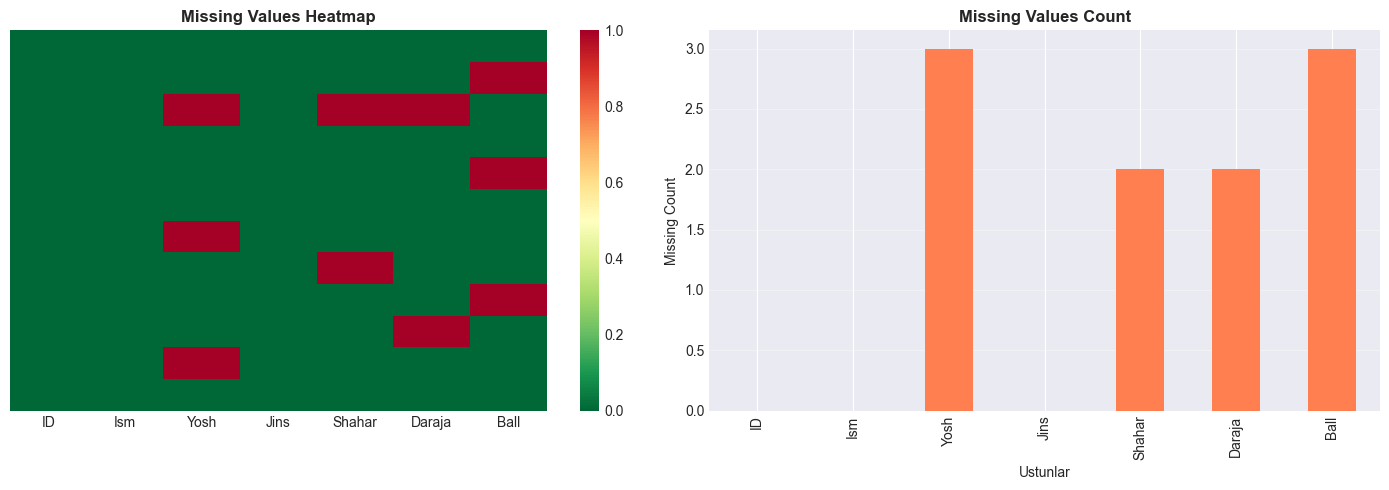

In [60]:
# STEP 1: Missing values ni aniqlash va vizualizatsiya
print("\n" + "="*60)
print("🔍 STEP 1: MISSING VALUES TAHLILI")
print("="*60)

missing_info = pd.DataFrame({
    'Missing Count': df_real.isnull().sum(),
    'Percentage': (df_real.isnull().sum() / len(df_real)) * 100
})
print(missing_info)

# Vizualizatsiya
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(df_real.isnull(), cbar=True, yticklabels=False, cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title('Missing Values Heatmap', fontweight='bold')

# Bar plot
df_real.isnull().sum().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Missing Values Count', fontweight='bold')
axes[1].set_xlabel('Ustunlar')
axes[1].set_ylabel('Missing Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# STEP 2: Takrorlarni aniqlash
print("\n" + "="*60)
print("🔍 STEP 2: TAKRORIY QATORLARNI ANIQLASH")
print("="*60)

# ID ustunini hisobga olmasdan takrorlarni qidirish
cols_to_check = ['Ism', 'Yosh', 'Jins', 'Shahar', 'Daraja', 'Ball']
duplicates_mask = df_real.duplicated(subset=cols_to_check, keep=False)

print(f"\n🔄 Takroriy qatorlar soni: {duplicates_mask.sum()}")
if duplicates_mask.sum() > 0:
    print("\nTakroriy qatorlar:")
    print(df_real[duplicates_mask].sort_values('Ism'))


🔍 STEP 2: TAKRORIY QATORLARNI ANIQLASH

🔄 Takroriy qatorlar soni: 2

Takroriy qatorlar:
   ID  Ism  Yosh   Jins    Shahar Daraja  Ball
0   1  Ali  20.0  Erkak  Toshkent  O'rta  85.0
5   6  Ali  20.0  Erkak  Toshkent  O'rta  85.0


In [62]:
# STEP 3: Ma'lumotlarni tozalash
print("\n" + "="*60)
print("🧹 STEP 3: MA'LUMOTLARNI TOZALASH")
print("="*60)

df_cleaned = df_real.copy()

# 3.1: Takrorlarni o'chirish (ID dan tashqari)
df_cleaned = df_cleaned.drop_duplicates(subset=cols_to_check, keep='first')
print(f"✅ Takrorlar o'chirildi: {len(df_real)} → {len(df_cleaned)} qator")

# 3.2: Missing values ni to'ldirish
# Yosh - median
df_cleaned['Yosh'] = df_cleaned['Yosh'].fillna(df_cleaned['Yosh'].median())
print(f"✅ Yosh to'ldirildi (median: {df_cleaned['Yosh'].median()})")

# Ball - mean
df_cleaned['Ball'] = df_cleaned['Ball'].fillna(df_cleaned['Ball'].mean())
print(f"✅ Ball to'ldirildi (mean: {df_cleaned['Ball'].mean():.2f})")

# Shahar - mode
df_cleaned['Shahar'] = df_cleaned['Shahar'].fillna(df_cleaned['Shahar'].mode()[0])
print(f"✅ Shahar to'ldirildi (mode: {df_cleaned['Shahar'].mode()[0]})")

# Daraja - mode
df_cleaned['Daraja'] = df_cleaned['Daraja'].fillna(df_cleaned['Daraja'].mode()[0])
print(f"✅ Daraja to'ldirildi (mode: {df_cleaned['Daraja'].mode()[0]})")

print("\n📊 TOZALANGAN MA'LUMOTLAR:")
print(df_cleaned)
print(f"\n✅ Missing values: {df_cleaned.isnull().sum().sum()}")


🧹 STEP 3: MA'LUMOTLARNI TOZALASH
✅ Takrorlar o'chirildi: 12 → 11 qator
✅ Yosh to'ldirildi (median: 22.0)
✅ Ball to'ldirildi (mean: 85.00)
✅ Shahar to'ldirildi (mode: Samarqand)
✅ Daraja to'ldirildi (mode: Yuqori)

📊 TOZALANGAN MA'LUMOTLAR:
    ID      Ism  Yosh   Jins     Shahar  Daraja  Ball
0    1      Ali  20.0  Erkak   Toshkent   O'rta  85.0
1    2     Vali  22.0  Erkak  Samarqand  Yuqori  85.0
2    3   Sardor  22.0  Erkak  Samarqand  Yuqori  92.0
3    4   Malika  21.0   Ayol   Toshkent  Yuqori  78.0
4    5   Nigora  23.0   Ayol     Buxoro   O'rta  85.0
6    7     Aziz  22.0  Erkak   Toshkent    Past  88.0
7    8  Dildora  20.0   Ayol  Samarqand  Yuqori  95.0
8    9    Jasur  22.0  Erkak  Samarqand   O'rta  85.0
9   10   Zarina  24.0   Ayol   Farg'ona  Yuqori  82.0
10  11    Kamol  22.0  Erkak     Buxoro    Past  70.0
11  12     Vali  22.0  Erkak  Samarqand  Yuqori  90.0

✅ Missing values: 0


In [63]:
# STEP 4: Categorical Encoding
print("\n" + "="*60)
print("🔢 STEP 4: CATEGORICAL ENCODING")
print("="*60)

df_encoded = df_cleaned.copy()

# 4.1: Jins - Label Encoding (binary)
jins_map = {'Erkak': 0, 'Ayol': 1}
df_encoded['Jins'] = df_encoded['Jins'].map(jins_map)
print("✅ Jins encoded (Label Encoding)")

# 4.2: Daraja - Ordinal Encoding
daraja_map = {'Past': 0, "O'rta": 1, 'Yuqori': 2}
df_encoded['Daraja'] = df_encoded['Daraja'].map(daraja_map)
print("✅ Daraja encoded (Ordinal Encoding)")

# 4.3: Shahar - One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=['Shahar'], prefix='Shahar', drop_first=True)
print("✅ Shahar encoded (One-Hot Encoding)")

# Ism ustunini o'chirish (ML uchun kerak emas)
df_final = df_encoded.drop(['Ism'], axis=1)

print("\n📊 YAKUNIY MA'LUMOTLAR (ML uchun tayyor):")
print(df_final)
print(f"\n📏 Yakuniy o'lcham: {df_final.shape}")
print(f"✅ Barcha ustunlar raqamli: {df_final.select_dtypes(include=[np.number]).shape[1]}/{len(df_final.columns)}")


🔢 STEP 4: CATEGORICAL ENCODING
✅ Jins encoded (Label Encoding)
✅ Daraja encoded (Ordinal Encoding)
✅ Shahar encoded (One-Hot Encoding)

📊 YAKUNIY MA'LUMOTLAR (ML uchun tayyor):
    ID  Yosh  Jins  Daraja  Ball  Shahar_Farg'ona  Shahar_Samarqand  \
0    1  20.0     0       1  85.0            False             False   
1    2  22.0     0       2  85.0            False              True   
2    3  22.0     0       2  92.0            False              True   
3    4  21.0     1       2  78.0            False             False   
4    5  23.0     1       1  85.0            False             False   
6    7  22.0     0       0  88.0            False             False   
7    8  20.0     1       2  95.0            False              True   
8    9  22.0     0       1  85.0            False              True   
9   10  24.0     1       2  82.0             True             False   
10  11  22.0     0       0  70.0            False             False   
11  12  22.0     0       2  90.0         

In [64]:
# STEP 5: Taqqoslash
print("\n" + "="*60)
print("📊 STEP 5: BOSHLANG'ICH VA YAKUNIY TAQQOSLASH")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Qatorlar soni', 'Ustunlar soni', 'Missing values', 'Duplicates', 'Kategorik ustunlar', 'Raqamli ustunlar'],
    'Boshlang\'ich': [
        len(df_real),
        len(df_real.columns),
        df_real.isnull().sum().sum(),
        df_real.duplicated().sum(),
        len(df_real.select_dtypes(include=['object']).columns),
        len(df_real.select_dtypes(include=[np.number]).columns)
    ],
    'Yakuniy': [
        len(df_final),
        len(df_final.columns),
        df_final.isnull().sum().sum(),
        df_final.duplicated().sum(),
        len(df_final.select_dtypes(include=['object']).columns),
        len(df_final.select_dtypes(include=[np.number]).columns)
    ]
})

print(comparison.to_string(index=False))
print("\n" + "="*60)
print("✅ MA'LUMOTLAR MACHINE LEARNING UCHUN TAYYOR!")
print("="*60)


📊 STEP 5: BOSHLANG'ICH VA YAKUNIY TAQQOSLASH
            Metric  Boshlang'ich  Yakuniy
     Qatorlar soni            12       11
     Ustunlar soni             7        8
    Missing values            10        0
        Duplicates             0        0
Kategorik ustunlar             4        0
  Raqamli ustunlar             3        5

✅ MA'LUMOTLAR MACHINE LEARNING UCHUN TAYYOR!


---
## 📝 Xulosa

### Bugun nimalarni o'rgandik?

#### 1. Missing Values
- ✅ Missing values ni aniqlash: `isnull()`, `isna()`
- ✅ O'chirish: `dropna()`
- ✅ To'ldirish: `fillna()`, mean, median, mode
- ✅ SimpleImputer ishlatish

#### 2. Duplicates
- ✅ Takrorlarni aniqlash: `duplicated()`
- ✅ Takrorlarni o'chirish: `drop_duplicates()`
- ✅ Subset bo'yicha tekshirish

#### 3. Categorical Encoding
- ✅ Label Encoding - binary va ordinal
- ✅ Ordinal Encoding - tartibli kategoriyalar
- ✅ One-Hot Encoding - nominal kategoriyalar
- ✅ Qaysi usulni qachon ishlatish

#### 4. Real World Pipeline
- ✅ To'liq data cleaning jarayoni
- ✅ Bosqichma-bosqich amaliyot
- ✅ ML uchun ma'lumotlarni tayyorlash

### 🎯 Keyingi Qadamlar

1. **Amaliy mashg'ulot** - real ma'lumotlar bilan ishlash
2. **Uy vazifasi** - mustaqil loyiha
3. **Feature Engineering** - yangi featurelar yaratish
4. **Feature Scaling** - normalization va standardization

---
## 🔑 Key Takeaways

### Missing Values
```python
# Aniqlash
df.isnull().sum()

# O'chirish
df.dropna()

# To'ldirish
df.fillna(df.mean())  # mean
df.fillna(df.median())  # median
df.fillna(df.mode()[0])  # mode
```

### Duplicates
```python
# Aniqlash
df.duplicated()

# O'chirish
df.drop_duplicates()
```

### Encoding
```python
# Label Encoding
df['col'] = df['col'].map({'A': 0, 'B': 1})

# One-Hot Encoding
pd.get_dummies(df, columns=['col'])
```

### 💡 Muhim Qoidalar

1. **Har doim nusxa yarating**: `df.copy()`
2. **Missing values ni tushunib to'ldiring**: random emas, mantiqiy
3. **Takrorlarni tekshiring**: real yoki xato?
4. **To'g'ri encoding tanlang**: ordinal vs nominal
5. **Vizualizatsiya qiling**: ko'z bilan ko'ring

---
**Savollar?** 🙋‍♀️🙋‍♂️